In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [18]:
# Load dataset

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
df.shape

(200, 5)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [21]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [22]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

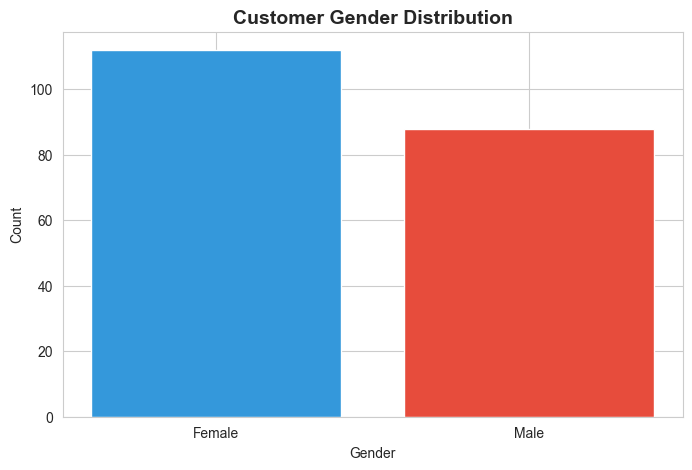

In [23]:
# Gender Distribution

plt.figure(figsize=(8,5))
gender_counts = df['Gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=['#3498db','#e74c3c'])
plt.title('Customer Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

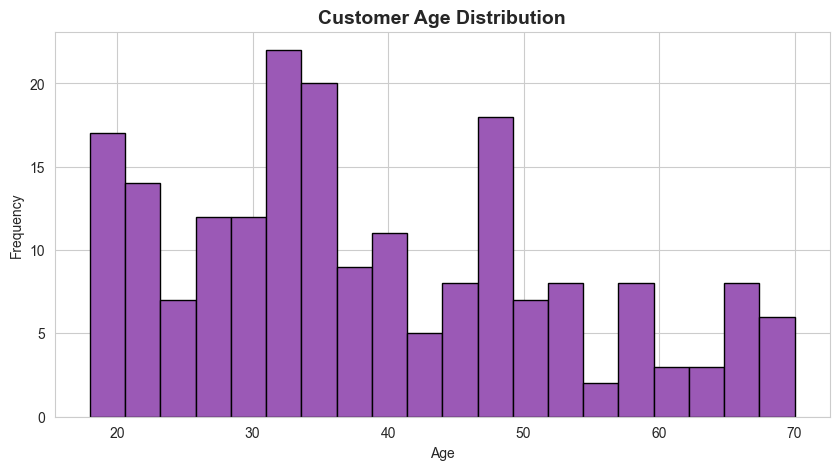

In [24]:
# Age Distribution

plt.figure(figsize=(10,5))
plt.hist(df['Age'], bins=20, color='#9b59b6', edgecolor='black')
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

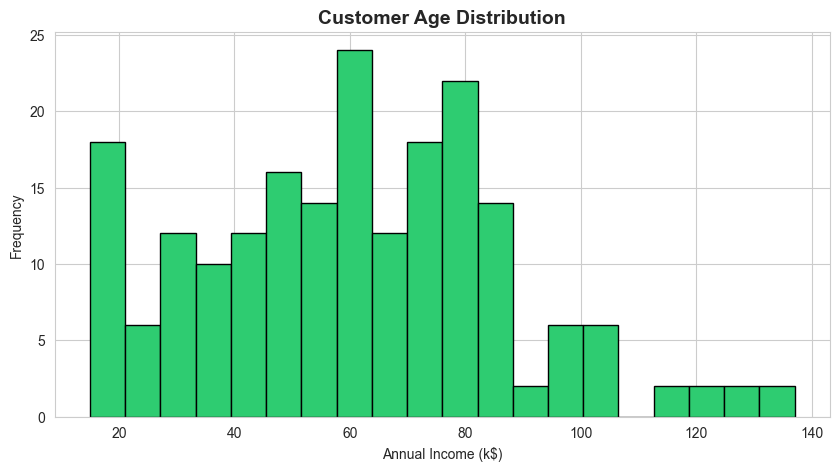

In [25]:
# Annual Income Distribution

plt.figure(figsize=(10,5))
plt.hist(df['Annual Income (k$)'], bins=20, color='#2ecc71', edgecolor='black')
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

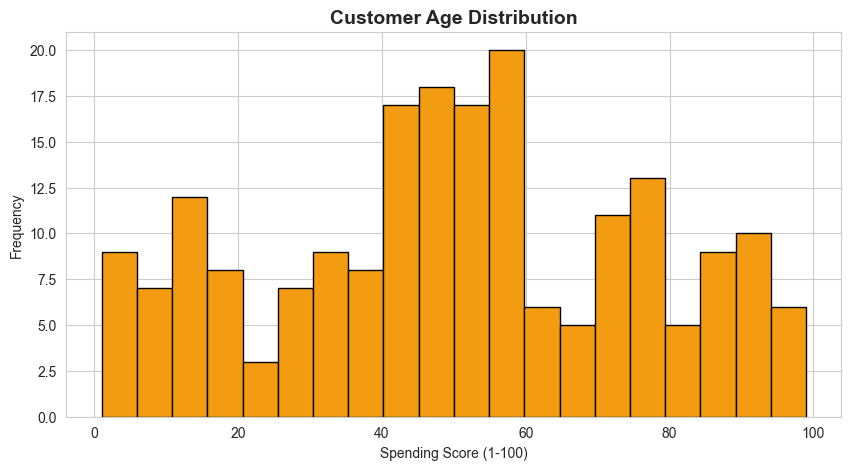

In [26]:
# Spending Score Distribution

plt.figure(figsize=(10,5))
plt.hist(df['Spending Score (1-100)'], bins=20, color='#f39c12', edgecolor='black')
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

In [27]:
x = df.iloc[:,[3,4]].values

In [28]:
# Calculate WCSS for different numbers of clusters

wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

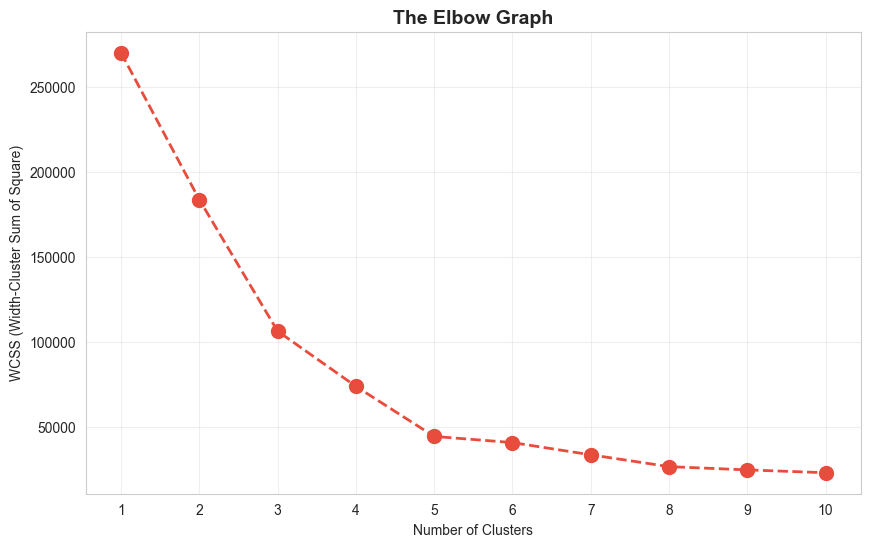

In [29]:
# Plot the elbow graph

plt.figure(figsize=(10,6))
plt.plot(range(1,11), wcss, marker='o', linestyle='--', color='#e74c3c', linewidth=2, markersize=10)
plt.title('The Elbow Graph', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Width-Cluster Sum of Square)')
plt.xticks(range(1,11))
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# Train with optimal clusters 

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y = kmeans.fit_predict(x)

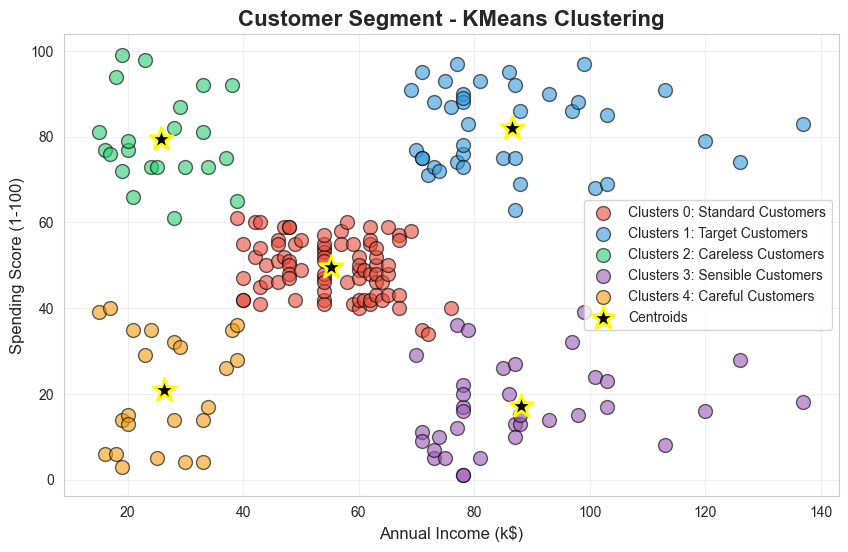

In [31]:
plt.figure(figsize=(10,6))

colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']
clusters_names = ['Standard Customers','Target Customers','Careless Customers','Sensible Customers','Careful Customers']

for i in range(5):
    plt.scatter(x[y==i,0], x[y==i,1], s=100, c=colors[i],
                label=f'Clusters {i}: {clusters_names[i]}', alpha=0.6, edgecolor='black')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=300, c='black', marker='*', label='Centroids', edgecolors='yellow', linewidth=2)

plt.title('Customer Segment - KMeans Clustering', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True,alpha=0.3)
plt.show()

In [32]:
df['Cluster'] = y

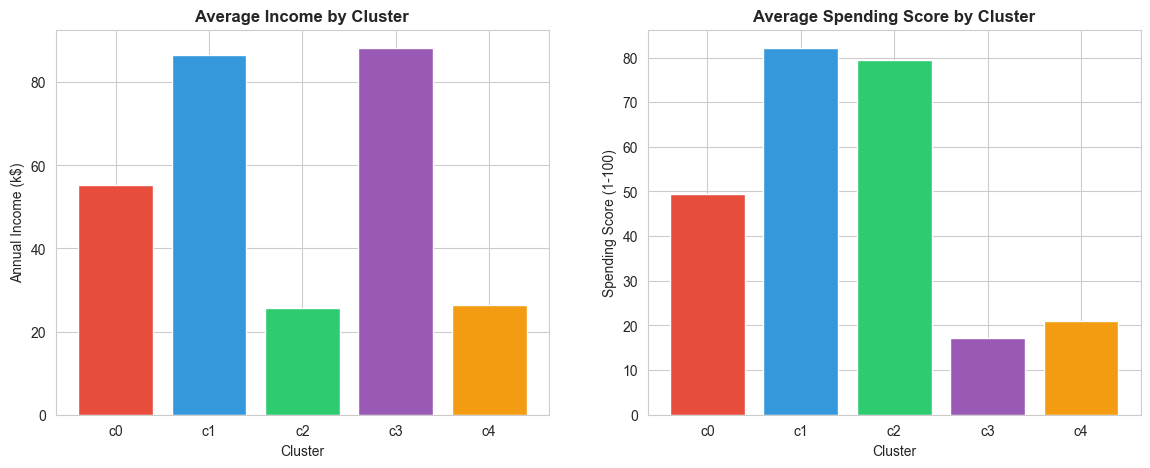

In [33]:
# Create comparison visualization
fig, axes = plt.subplots(1,2, figsize=(14,5))
 
# Income comparison
cluster_income = [df[df['Cluster']==i]['Annual Income (k$)'].mean()
                for i in range(5)]

axes[0].bar(range(5), cluster_income, color=colors)
axes[0].set_title('Average Income by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Annual Income (k$)')
axes[0].set_xticks(range(5))
axes[0].set_xticklabels([f'c{i}' for i in range(5)])

# Income comparison
cluster_spending = [df[df['Cluster']==i]['Spending Score (1-100)'].mean()
                  for i in range(5)]

axes[1].bar(range(5), cluster_spending, color=colors)
axes[1].set_title('Average Spending Score by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([f'c{i}' for i in range(5)])

plt.show()

In [34]:
# Example 
new_customer = np.array([[70,80]])  # Income :- 70k, Spending :- 80
predicted_cluster = kmeans.predict(new_customer)[0]

print(f'Customer (Income: ${new_customer[0][0]}k, Spending: {new_customer[0][1]}) -- Cluster {predicted_cluster}: {clusters_names[predicted_cluster]}')

Customer (Income: $70k, Spending: 80) -- Cluster 1: Target Customers


In [35]:
# Saving the Model

joblib.dump(kmeans, 'customer_segmentation_model.pkl')
print("Model Saved")

Model Saved
